<a href="https://colab.research.google.com/github/Rut092/AI-Journey-Practice/blob/main/Clustering_Practice(K_means%2CDBSCAN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## K-Means Clustering and Elbow Method

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

In [2]:
X,_ = make_blobs(n_samples=1000, centers=4, cluster_std=0.60, random_state=0)

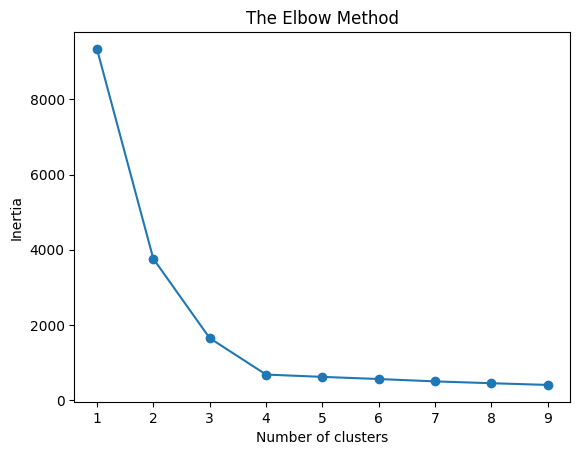

In [4]:
inertia = []
for i in range(1,10):
    # max_iter: Maximum number of iterations of the K-means algorithm for a single run.
    # n_init: Number of times the K-means algorithm will be run independently with different centroid seeds.
    #         The final results will be the best output of n_init consecutive runs in terms of inertia.
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.title('The Elbow Method')
plt.ylabel('Inertia')
plt.show()

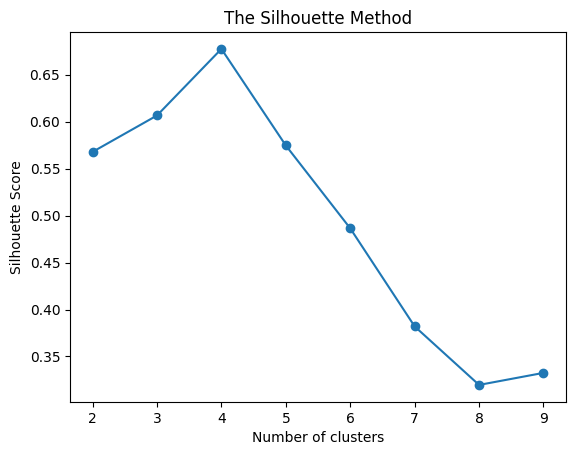

In [5]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
# Silhouette score is not defined for a single cluster, so we start from 2
for i in range(2,10):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X)
    score = silhouette_score(X, kmeans.labels_)
    silhouette_scores.append(score)

plt.plot(range(2,10), silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.title('The Silhouette Method')
plt.ylabel('Silhouette Score')
plt.show()

# 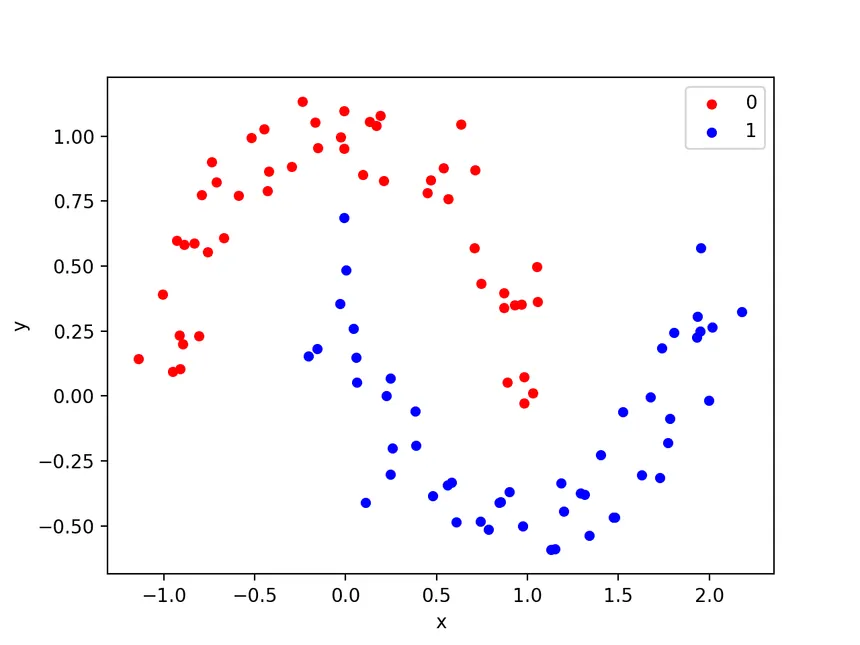

*K-means Failing for moon dataset(non-linear)*

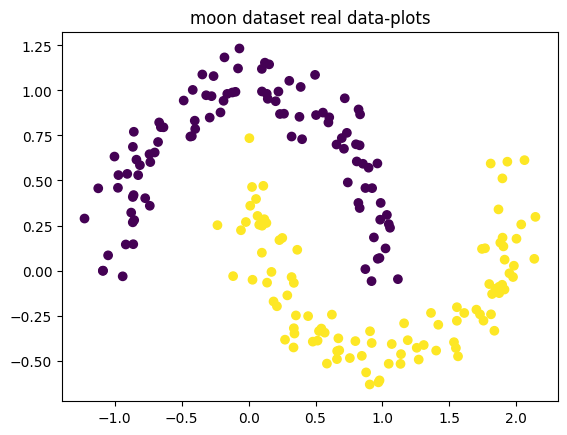

In [18]:
from sklearn.datasets import make_moons

X_moon, _label = make_moons(n_samples = 200,noise= 0.1,random_state=42)

plt.scatter(X_moon[:, 0], X_moon[:, 1], c=_label, cmap='viridis')
plt.title("moon dataset real data-plots")
plt.show()


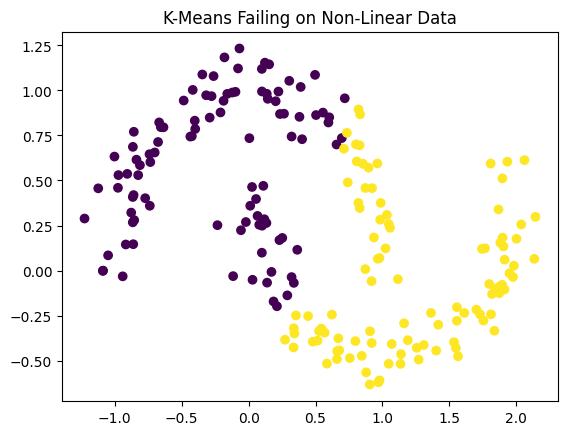

In [19]:
k_means_moon = KMeans(n_clusters=2,random_state=42)
moon_label = k_means_moon.fit_predict(X_moon)

plt.scatter(X_moon[:, 0], X_moon[:, 1], c=moon_label, cmap='viridis')
plt.title("K-Means Failing on Non-Linear Data")
plt.show()

## Trying Moon Dataset with DBSCAN Algo

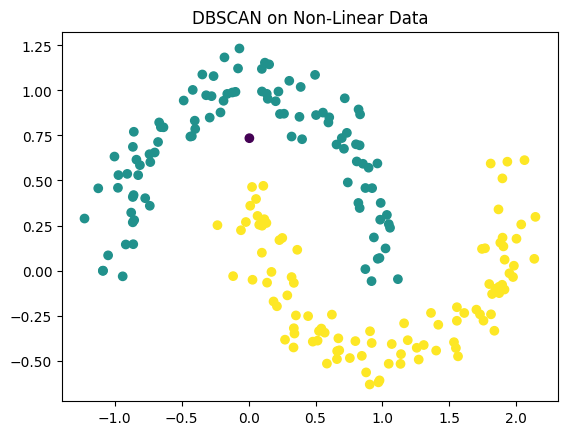

In [38]:
from sklearn.cluster import DBSCAN

db_scan = DBSCAN(eps=0.22,min_samples=5)
moon_label = db_scan.fit_predict(X_moon)

plt.scatter(X_moon[:, 0], X_moon[:, 1], c=moon_label, cmap='viridis')
plt.title("DBSCAN on Non-Linear Data")
plt.show()

# How do we select the perfect value of Epsilon ?

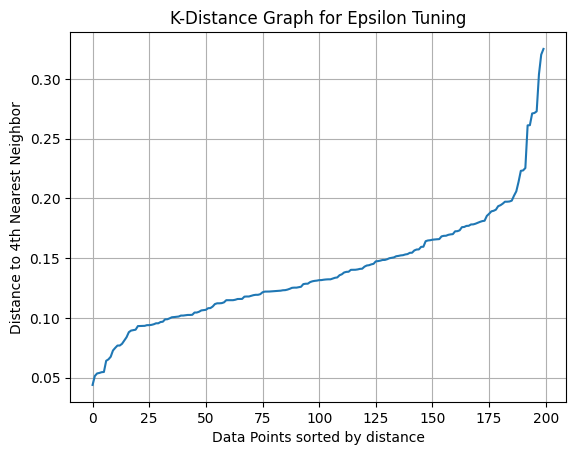

In [33]:
from sklearn.neighbors import NearestNeighbors

# 1.min_samples should be 4 (based on 2D data) like 2*no. of features
k = 4
# 2. Fit a NearestNeighbors model to calculate the distances
# (We use k+1 because the point's closest neighbor is always itself at distance 0)
n_neighbors = NearestNeighbors(n_neighbors=k+1)
n_neighbors.fit(X_moon)
distances, indices = n_neighbors.kneighbors(X_moon)

k_distances = np.sort(distances[:,-1])

plt.plot(k_distances)
plt.title("K-Distance Graph for Epsilon Tuning")
plt.xlabel("Data Points sorted by distance")
plt.ylabel(f"Distance to {k}th Nearest Neighbor")
plt.grid(True)
plt.show()
